In [4]:
# Labial 

import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from model_unified_ver import run_exp
from model_unified_ver import default_params as params
import utils as utl
from analysis_of_simulation_result import * 

import numpy as np 
import pandas as pd 
import os 
import pickle
from fitting import * 
from make_network import *
sez_ids = np.concatenate(list(sez.values()))
sez_id2g = {f:g for g,fid in sez.items() for f in fid}

av1a1 = [720575940623041549,720575940622894616,720575940626958878,720575940633984924,720575940611137742,720575940627192337]
        
c2g = dict(zip(target_ids_valid_all,g_info_all))


In [5]:
params_opt_tarsal = pickle.load(open(REPO_ROOT/'figure4/figure4F-K.MN9_PER_fitting/fitting_result/tarsal/result_av1a1_170.pkl','rb'))
params_opt_labial = pickle.load(open(REPO_ROOT/'figure4/figure4F-K.MN9_PER_fitting/fitting_result/labial/result_av1a1_170.pkl','rb'))

V_l1l2,K_l1l2,n_l1l2,V_l3,K_l3,n_l3,k_act_L,r0_L,h_L = params_opt_labial.x
V_at,K_at,n_at,V_tp,K_tp,n_tp,k_act_T,r0_T,h_T = params_opt_tarsal.x


firing_labial = [(0,0),*[(np.round(hill(c,V_l1l2,K_l1l2,n_l1l2),1),np.round(hill(c,V_l3,K_l3,n_l3),1)) for c in [10,50,100,500]]]
firing_tarsal = [(0,0),*[(np.round(hill(c,V_at,K_at,n_at),1),np.round(hill(c,V_tp,K_tp,n_tp),1)) for c in [10,50,100,500]]]


popt_labial = [k_act_L,r0_L,h_L]
popt_tarsal = [k_act_T,r0_T,h_T]


In [8]:
def get_val_each_trial(spikes,popt,mode='PER'):
    concents = [0,10,50,100,500]
    val_per_concent = {}
    for j,g in enumerate(concents):
        trials = np.zeros(100)
        for i,t_df in spikes[j].groupby(by='trial'):
            trials[t_df.trial.values[0]] = len(t_df)/2
        if mode == 'PER':
            y = sigmoid(trials,*popt)
        elif mode == 'MN9':
            y = trials
        val_per_concent[g] = y
    return val_per_concent


def get_error(spikes,popt,mode='PER'):
    concents = [0,10,50,100,500]
    std_control = {}
    for j,g in enumerate(concents):
        trials = np.zeros(100)
        for i,t_df in spikes[j].groupby(by='trial'):
            trials[t_df.trial.values[0]] = len(t_df)/2
        if mode == 'PER':
            y = sigmoid(trials,*popt)
        elif mode == 'MN9':
            y = trials
        std_control[g] = np.std(y)/np.sqrt(len(y))
    return std_control

In [61]:
# path = f'{os.getcwd()}/labial/result_control'
# total_paths = [f'{path}/{ff1}Hz_{ff2}Hz_170Hz.parquet' for ff1,ff2 in firing_labial]
# rates_inhibition_clamped_labial,spikes_inhibition_clamped_labial,std = read_result_with_multi_thread(total_paths,mn9,'MN9')


# path = '/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure4/PER_fitting/Seperate_fitting_subtype_all_at_once/convert_simulation_result/result_L1L2&L3'
# total_paths = [f'{path}/{ff1}Hz_{ff2}Hz_170Hz.parquet' for ff1,ff2 in firing_labial]
# rates_control_labial,spikes_control_labial,std = read_result_with_multi_thread(total_paths,mn9,'MN9')

# path = f'{os.getcwd()}/tarsal/result_control'
# total_paths = [f'{path}/{ff1}Hz_{ff2}Hz_170Hz.parquet' for ff1,ff2 in firing_tarsal]
# rates_inhibition_clamped_tarsal,spikes_inhibition_clamped_tarsal,std = read_result_with_multi_thread(total_paths,mn9,'MN9')

# path = '/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure4/PER_fitting/Seperate_fitting_subtype_all_at_once/convert_simulation_result/result_atGRN&TPN1'
# total_paths = [f'{path}/{ff1}Hz_{ff2}Hz_170Hz.parquet' for ff1,ff2 in firing_tarsal]
# rates_control_tarsal,spikes_control_tarsal,std = read_result_with_multi_thread(total_paths,mn9,'MN9')


# df_control = {}
# df_clamped = {}
# error_control = {}
# error_clamped = {}
# df_control['labial'] = sigmoid(pd.concat(rates_control_labial,axis=1),*popt_labial)
# df_clamped['labial'] = sigmoid(pd.concat(rates_inhibition_clamped_labial,axis=1),*popt_labial)

# df_control['tarsal'] = sigmoid(pd.concat(rates_control_tarsal,axis=1),*popt_tarsal)
# df_clamped['tarsal'] = sigmoid(pd.concat(rates_inhibition_clamped_tarsal,axis=1),*popt_tarsal)

# error_control['labial'] = get_error(spikes_control_labial,popt_labial,mode='PER')
# error_control['tarsal'] = get_error(spikes_control_tarsal,popt_tarsal,mode='PER')

# error_clamped['labial'] = get_error(spikes_inhibition_clamped_labial,popt_labial,mode='PER')
# error_clamped['tarsal'] = get_error(spikes_inhibition_clamped_tarsal,popt_tarsal,mode='PER')

# conc = [0, 10, 50, 100, 500]

# pivot_control = pd.DataFrame({
#     'labial': df_control['labial'].loc['MN9'].values,
#     'tarsal': df_control['tarsal'].loc['MN9'].values
# }, index=conc).T

# pivot_err_control = pd.DataFrame({
#     'labial': error_control['labial'].values(),
#     'tarsal': error_control['tarsal'].values()
# }, index=conc).T

# pivot_clamped = pd.DataFrame({
#     'labial': df_clamped['labial'].loc['MN9'].values,
#     'tarsal': df_clamped['tarsal'].loc['MN9'].values
# }, index=conc).T

# pivot_err_clamped = pd.DataFrame({
#     'labial': error_clamped['labial'].values(),
#     'tarsal': error_clamped['tarsal'].values()
# }, index=conc).T

pivot_clamped = pd.read_parquet('result_data/data_clamped.parquet')
pivot_err_clamped = pd.read_parquet('result_data/sem_clamped.parquet')
pivot_control = pd.read_parquet('result_data/data_control.parquet')
pivot_err_control = pd.read_parquet('result_data/sem_control.parquet')


spikes_control_labial = pickle.load(open('result_data/spikes_control_labial.pkl','rb'))
spikes_inhibition_clamped_labial = pickle.load(open('result_data/spikes_clamped_labial.pkl','rb'))
spikes_control_tarsal = pickle.load(open('result_data/spikes_control_tarsal.pkl','rb'))
spikes_inhibition_clamped_tarsal = pickle.load(open('result_data/spikes_clamped_tarsal.pkl','rb'))

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

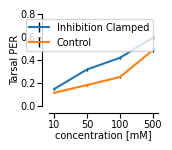

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

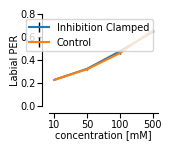

In [62]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7


for i,t in enumerate(['tarsal','labial']):
    fig,ax = plt.subplots(1,1,figsize=(1.4,1.2))
    
    wo = pivot_clamped.loc[t].T.iloc[1:]
    control = pivot_control.loc[t].T.iloc[1:]
    
    ax.errorbar([0,1,2,3],wo.values,yerr=[error_wo[t][x] for x in [10,50,100,500]],ecolor='black',elinewidth=1,label='Inhibition Clamped')
    ax.errorbar([0,1,2,3],control.values,yerr=[error_control[t][x] for x in [10,50,100,500]],ecolor='black',elinewidth=1,label='Control')

    ax.set_xticks([0,1,2,3],[10,50,100,500])
    ax.set_xlabel('concentration [mM]')
    ax.set_yticks(list(np.arange(0,1,.2)),np.round(list(np.arange(0,1,.2)),2))
    ax.spines[['top','right']].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.xaxis.labelpad = 0.5
    ax.yaxis.labelpad = 0.5
    ax.tick_params(pad=1)
    ax.set_ylabel(f'{t.capitalize()} PER')
    ax.legend()
#     plt.savefig(f'Inhibition_effect_{t}-PER.svg')

In [63]:
# statistical tests 

import pandas as pd
from scipy.stats import shapiro,ttest_rel
concentrations = [10,50,100,500]

a = get_val_each_trial(spikes_control_tarsal, popt_tarsal, mode='PER')
b = get_val_each_trial(spikes_inhibition_clamped_tarsal, popt_tarsal, mode='PER')

c = get_val_each_trial(spikes_control_labial, popt_labial, mode='PER')
d = get_val_each_trial(spikes_inhibition_clamped_labial, popt_labial, mode='PER')

datasets = {
    "a": a,
    "b": b,
    "c": c,
    "d": d,
}

for name, data in datasets.items():
    print(f"\n{name}")
    for conc in sorted(data.keys()):
        result = shapiro(data[conc])
        print(
            f"{conc:>3} mM: "
            f"W = {result.statistic:.3e}, "
            f"p = {result.pvalue:.3e}"
        )


a
  0 mM: W = 1.000e+00, p = 1.000e+00
 10 mM: W = 6.617e-01, p = 7.535e-14
 50 mM: W = 8.606e-01, p = 2.970e-08
100 mM: W = 9.390e-01, p = 1.677e-04
500 mM: W = 9.726e-01, p = 3.495e-02

b
  0 mM: W = 1.000e+00, p = 1.000e+00
 10 mM: W = 8.403e-01, p = 5.262e-09
 50 mM: W = 9.643e-01, p = 8.186e-03
100 mM: W = 9.781e-01, p = 9.366e-02
500 mM: W = 9.654e-01, p = 9.962e-03

c
  0 mM: W = 7.519e-02, p = 3.371e-22
 10 mM: W = 1.477e-01, p = 1.928e-21
 50 mM: W = 9.621e-01, p = 5.679e-03
100 mM: W = 9.810e-01, p = 1.587e-01
500 mM: W = 9.863e-01, p = 3.925e-01

d
  0 mM: W = 1.000e+00, p = 1.000e+00
 10 mM: W = 7.519e-02, p = 3.371e-22
 50 mM: W = 9.815e-01, p = 1.744e-01
100 mM: W = 9.779e-01, p = 9.031e-02
500 mM: W = 9.620e-01, p = 5.586e-03


In [64]:
for conc in concentrations:
    delta_tarsal = a[conc] - b[conc]
    

    W, p = shapiro(delta_tarsal)

    print(f"{conc} mM", f"W = {W}", f"p = {p}")
    
for conc in concentrations:
    delta_labial = c[conc] - d[conc]
    

    W, p = shapiro(delta_labial)

    print(f"{conc} mM", f"W = {W}", f"p = {p}")    
    

10 mM W = 0.9341087014785092 p = 8.579739304021244e-05
50 mM W = 0.9873524448913065 p = 0.4617531819593785
100 mM W = 0.994115414826714 p = 0.9453469999486017
500 mM W = 0.9889843286213796 p = 0.5833375351958295
10 mM W = 0.18092550911961225 p = 4.457236896964339e-21
50 mM W = 0.9881670906645741 p = 0.5206081243321844
100 mM W = 0.9833546951657391 p = 0.24030384040092878
500 mM W = 0.9844778316975419 p = 0.2910388766017158


In [66]:
from scipy.stats import wilcoxon
print('######### Tarsal, control vs. inhibition fixed')
for conc in [10,50,100,500]:

    result = wilcoxon(
        b[conc],
        a[conc],
        alternative="two-sided"
    )

    print(
        f"{conc:>3} mM: "
#         f"ΔTarsal = {delta_tarsal.mean():.3e}, "
#         f"ΔLabial = {delta_labial.mean():.3e}, "
        f"W = {result.statistic:.3e}, "
        f"p = {result.pvalue:.3e}"
    )
    
    
print('######### labellar, control vs. inhibition fixed')
for conc in [10,50,100,500]:

    result = wilcoxon(
        d[conc],
        c[conc],
        alternative="two-sided"
    )

    print(
        f"{conc:>3} mM: "
#         f"ΔTarsal = {delta_tarsal.mean():.3e}, "
#         f"ΔLabial = {delta_labial.mean():.3e}, "
        f"W = {result.statistic:.3e}, "
        f"p = {result.pvalue:.3e}"
    )

######### Tarsal, control vs. inhibition fixed
 10 mM: W = 8.565e+02, p = 3.436e-05
 50 mM: W = 4.355e+02, p = 2.863e-12
100 mM: W = 4.435e+02, p = 1.335e-12
500 mM: W = 1.010e+03, p = 1.448e-06
######### labellar, control vs. inhibition fixed
 10 mM: W = 2.000e+00, p = 5.930e-01
 50 mM: W = 1.894e+03, p = 4.297e-01
100 mM: W = 1.794e+03, p = 7.153e-02
500 mM: W = 1.574e+03, p = 1.913e-02


In [68]:
for conc in concentrations:
    delta_tarsal = a[conc] - b[conc]
    delta_labial = c[conc] - d[conc]

    diff = delta_tarsal - delta_labial

    W, p = shapiro(diff)

    print(f"{conc} mM", f"W = {W}", f"p = {p}")

10 mM W = 0.9293690890339591 p = 4.583815433414894e-05
50 mM W = 0.9868801088968421 p = 0.42961447871638336
100 mM W = 0.9914749826156016 p = 0.782021567003381
500 mM W = 0.9856149182822561 p = 0.351384979319343
